In [17]:
import pandas as pd
df=pd.read_csv("auto_mpg.csv")
print(df)

      mpg  cylinders  displacement  horsepower  weight  acceleration  \
0    18.0          8         307.0       130.0    3504          12.0   
1    15.0          8         350.0       165.0    3693          11.5   
2    18.0          8         318.0       150.0    3436          11.0   
3    16.0          8         304.0       150.0    3433          12.0   
4    17.0          8         302.0       140.0    3449          10.5   
..    ...        ...           ...         ...     ...           ...   
393  27.0          4         140.0        86.0    2790          15.6   
394  44.0          4          97.0        52.0    2130          24.6   
395  32.0          4         135.0        84.0    2295          11.6   
396  28.0          4         120.0        79.0    2625          18.6   
397  31.0          4         119.0        82.0    2720          19.4   

     model_year  origin                       name  
0            70     usa  chevrolet chevelle malibu  
1            70     usa      

In [18]:
df.drop('name',axis=1,inplace=True)
print(df.columns)

Index(['mpg', 'cylinders', 'displacement', 'horsepower', 'weight',
       'acceleration', 'model_year', 'origin'],
      dtype='object')


In [19]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['origin']=le.fit_transform(df['origin'])
print(df)

      mpg  cylinders  displacement  horsepower  weight  acceleration  \
0    18.0          8         307.0       130.0    3504          12.0   
1    15.0          8         350.0       165.0    3693          11.5   
2    18.0          8         318.0       150.0    3436          11.0   
3    16.0          8         304.0       150.0    3433          12.0   
4    17.0          8         302.0       140.0    3449          10.5   
..    ...        ...           ...         ...     ...           ...   
393  27.0          4         140.0        86.0    2790          15.6   
394  44.0          4          97.0        52.0    2130          24.6   
395  32.0          4         135.0        84.0    2295          11.6   
396  28.0          4         120.0        79.0    2625          18.6   
397  31.0          4         119.0        82.0    2720          19.4   

     model_year  origin  
0            70       2  
1            70       2  
2            70       2  
3            70       2  
4    

In [20]:
print(df['origin'].unique())

[2 1 0]


In [21]:
df.isnull().sum()

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64

In [22]:
df.fillna(method='ffill',inplace=True)
df.isnull().sum()

C:\Users\HP\AppData\Local\Temp\ipykernel_7740\627222060.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill',inplace=True)


mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model_year      0
origin          0
dtype: int64

In [23]:
x=df.iloc[:,1:8]
y=df[['mpg']]
print(x)


     cylinders  displacement  horsepower  weight  acceleration  model_year  \
0            8         307.0       130.0    3504          12.0          70   
1            8         350.0       165.0    3693          11.5          70   
2            8         318.0       150.0    3436          11.0          70   
3            8         304.0       150.0    3433          12.0          70   
4            8         302.0       140.0    3449          10.5          70   
..         ...           ...         ...     ...           ...         ...   
393          4         140.0        86.0    2790          15.6          82   
394          4          97.0        52.0    2130          24.6          82   
395          4         135.0        84.0    2295          11.6          82   
396          4         120.0        79.0    2625          18.6          82   
397          4         119.0        82.0    2720          19.4          82   

     origin  
0         2  
1         2  
2         2  
3      

In [24]:
print(y)

      mpg
0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
..    ...
393  27.0
394  44.0
395  32.0
396  28.0
397  31.0

[398 rows x 1 columns]


In [25]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)
print('Training set size:',x_train.shape[0])
print('Testing set size:',x_test.shape[0])

Training set size: 318
Testing set size: 80


In [26]:
x_train

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
394,4,97.0,52.0,2130,24.6,82,0
259,6,200.0,85.0,3070,16.7,78,2
326,4,90.0,48.0,2335,23.7,80,0
69,8,350.0,160.0,4456,13.5,72,2
135,6,225.0,105.0,3613,16.5,74,2
...,...,...,...,...,...,...,...
132,4,140.0,75.0,2542,17.0,74,2
213,8,350.0,145.0,4055,12.0,76,2
199,6,225.0,100.0,3651,17.7,76,2
113,6,155.0,107.0,2472,14.0,73,2


In [27]:
x_test

,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
143,4,97.0,78.0,2300,14.5,74,0
232,8,351.0,149.0,4335,14.5,77,2
280,6,231.0,115.0,3245,15.4,79,2
254,6,200.0,85.0,2965,15.8,78,2
222,8,260.0,110.0,4060,19.0,77,2
...,...,...,...,...,...,...,...
250,8,318.0,140.0,3735,13.2,78,2
182,4,107.0,86.0,2464,15.5,76,0
177,4,115.0,95.0,2694,15.0,75,0
229,8,400.0,180.0,4220,11.1,77,2


In [28]:
y_train

,mpg
394,44.0
259,20.8
326,43.4
69,12.0
135,18.0
...,...
132,25.0
213,13.0
199,20.0
113,21.0


In [29]:
y_test

,mpg
143,26.0
232,16.0
280,21.5
254,20.2
222,17.0
...,...
250,19.4
182,28.0
177,23.0
229,16.0


In [30]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(x_train, y_train)

y_pred = lr.predict(x_test)

print("Predicted MPG values:")
print(y_pred)


Predicted MPG values:
[[27.84432801]
 [15.97447805]
 [23.79144933]
 [24.8091865 ]
 [17.22673244]
 [25.85412869]
 [10.17366891]
 [30.90606032]
 [26.57289985]
 [27.30372484]
 [15.21076021]
 [25.71846018]
 [25.51837003]
 [27.88864401]
 [20.87146788]
 [28.36397425]
 [23.52054548]
 [20.46595267]
 [17.82558419]
 [23.6204955 ]
 [19.26402602]
 [28.12051129]
 [29.12560168]
 [28.98713887]
 [25.9253738 ]
 [30.12801494]
 [15.27506519]
 [16.90035153]
 [27.59767767]
 [28.91931781]
 [32.7615823 ]
 [24.94384445]
 [33.25129575]
 [33.7825084 ]
 [30.00186235]
 [23.68740719]
 [29.98905598]
 [22.60343354]
 [26.76689773]
 [32.641858  ]
 [ 9.86761343]
 [34.10407172]
 [10.09690797]
 [34.34969247]
 [17.32448451]
 [ 8.39529922]
 [16.49323828]
 [28.41084956]
 [12.65833829]
 [32.07083989]
 [34.52123177]
 [10.2316012 ]
 [16.5265835 ]
 [23.92076483]
 [25.60052215]
 [21.43256438]
 [26.63989207]
 [21.07322304]
 [10.82608048]
 [17.22951805]
 [19.47184165]
 [30.83062613]
 [20.40781785]
 [27.12374819]
 [24.06633989]
 [1

In [31]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
print("Mean squared error:",mse)
print("Mean absoulate error:",mae)
print("R_squared score:",r2)

Mean squared error: 11.392904281665363
Mean absoulate error: 2.691616968301972
R_squared score: 0.7838351813526563


In [32]:
import numpy as np
rmse=np.sqrt(mse)
print(rmse)

3.375337654467381


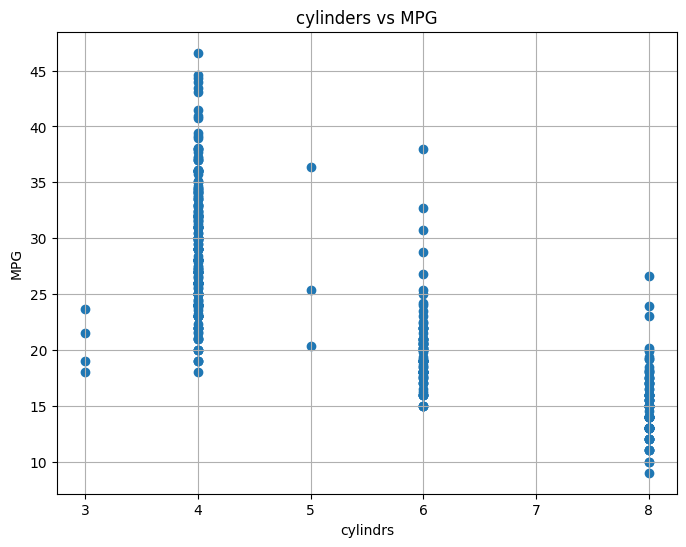

In [33]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,6))
plt.scatter(x['cylinders'],y)
plt.title("cylinders vs MPG")
plt.xlabel('cylindrs')
plt.ylabel('MPG')
plt.grid(True)
plt.show()